In [4]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report


In [5]:
print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
IMG_SIZE = (260, 260)
BATCH_SIZE = 16
EPOCHS_INITIAL = 10
EPOCHS_FINE = 25        # ⬆️ more fine-tuning = higher accuracy
SEED = 42

DATA_DIR = "/kaggle/input/food41/images"
CHECKPOINT_PATH = "/kaggle/working/best_effnetb3.keras"


In [7]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Number of classes:", num_classes)


Found 101000 files belonging to 101 classes.
Using 80800 files for training.


I0000 00:00:1766079246.907954      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 101000 files belonging to 101 classes.
Using 20200 files for validation.
Number of classes: 101


In [8]:
def one_hot(image, label):
    label = tf.cast(label, tf.int32)
    return image, tf.one_hot(label, num_classes)

train_ds = train_ds.map(one_hot, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(one_hot, num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)


In [9]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.3),
])

In [10]:
base_model = tf.keras.applications.EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=(260, 260, 3)
)

base_model.trainable = False

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
inputs = keras.Input(shape=(260, 260, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)


In [12]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 260, 260, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 260, 260, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 9, 9, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 101)            │       155,237 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,944,916 (41.75 MB)

 Trainable params: 158,309 (618.39 KB)

 Non-trainable params: 10,786,607 (41.15 MB)

In [13]:
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    CHECKPOINT_PATH,
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

lr_cb = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)


In [14]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_INITIAL,
    callbacks=[checkpoint_cb, lr_cb]
)


Epoch 1/10


E0000 00:00:1766079282.450050      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1766079285.390555     129 cuda_dnn.cc:529] Loaded cuDNN version 91002


5050/5050 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.3179 - loss: 3.6033
Epoch 1: val_accuracy improved from -inf to 0.61248, saving model to /kaggle/working/best_effnetb3.keras
5050/5050 ━━━━━━━━━━━━━━━━━━━━ 449s 85ms/step - accuracy: 0.3179 - loss: 3.6032 - val_accuracy: 0.6125 - val_loss: 2.1411 - learning_rate: 0.0010
Epoch 2/10
5050/5050 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.4595 - loss: 2.7404
Epoch 2: val_accuracy improved from 0.61248 to 0.63084, saving model to /kaggle/working/best_effnetb3.keras
5050/5050 ━━━━━━━━━━━━━━━━━━━━ 438s 87ms/step - accuracy: 0.4595 - loss: 2.7404 - val_accuracy: 0.6308 - val_loss: 2.0542 - learning_rate: 0.0010
Epoch 3/10
5050/5050 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.4870 - loss: 2.5739
Epoch 3: val_accuracy improved from 0.63084 to 0.63678, saving model to /kaggle/working/best_effnetb3.keras
5050/5050 ━━━━━━━━━━━━━━━━━━━━ 438s 87ms/step - accuracy: 0.4870 - loss: 2.5739 - val_accuracy: 0.6368 - val_loss: 2.0339 - learnin

In [15]:
base_model.trainable = True
for layer in base_model.layers[:-120]:
    layer.trainable = False


In [16]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)


In [17]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE,
    callbacks=[checkpoint_cb, lr_cb]
)


Epoch 1/25


E0000 00:00:1766083665.910527      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


5050/5050 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.5378 - loss: 2.3964
Epoch 1: val_accuracy improved from 0.65322 to 0.75817, saving model to /kaggle/working/best_effnetb3.keras
5050/5050 ━━━━━━━━━━━━━━━━━━━━ 674s 128ms/step - accuracy: 0.5379 - loss: 2.3964 - val_accuracy: 0.7582 - val_loss: 1.6744 - learning_rate: 1.0000e-04
Epoch 2/25
5050/5050 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.6875 - loss: 1.8977
Epoch 2: val_accuracy improved from 0.75817 to 0.78134, saving model to /kaggle/working/best_effnetb3.keras
5050/5050 ━━━━━━━━━━━━━━━━━━━━ 641s 127ms/step - accuracy: 0.6875 - loss: 1.8977 - val_accuracy: 0.7813 - val_loss: 1.5835 - learning_rate: 1.0000e-04
Epoch 3/25
5050/5050 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.7330 - loss: 1.7336
Epoch 3: val_accuracy improved from 0.78134 to 0.79708, saving model to /kaggle/working/best_effnetb3.keras
5050/5050 ━━━━━━━━━━━━━━━━━━━━ 640s 127ms/step - accuracy: 0.7330 - loss: 1.7336 - val_accuracy: 0.7971 - val_loss:

In [18]:
model = keras.models.load_model(CHECKPOINT_PATH)


In [19]:
loss, acc = model.evaluate(val_ds)
print(f" Validation Accuracy: {acc:.4f}")


1263/1263 ━━━━━━━━━━━━━━━━━━━━ 90s 65ms/step - accuracy: 0.8302 - loss: 1.4114
Final Validation Accuracy: 0.8275


In [49]:
from tensorflow import keras

model = keras.models.load_model("/kaggle/working/best_effnetb3.keras")
print("✅ Loaded best checkpoint")


✅ Loaded best checkpoint


In [50]:
model = keras.models.load_model("/kaggle/working/best_effnetb3.keras")


In [51]:
base_model.trainable = True

for layer in base_model.layers[:-60]:
    layer.trainable = False


In [52]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)


In [53]:
history_more = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[checkpoint_cb, lr_cb]
)


Epoch 1/10


E0000 00:00:1766102587.470587      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


5050/5050 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9670 - loss: 0.9714
Epoch 1: val_accuracy improved from 0.82748 to 0.82876, saving model to /kaggle/working/best_effnetb3.keras
5050/5050 ━━━━━━━━━━━━━━━━━━━━ 667s 127ms/step - accuracy: 0.9670 - loss: 0.9714 - val_accuracy: 0.8288 - val_loss: 1.4148 - learning_rate: 1.0000e-05
Epoch 2/10
5050/5050 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9655 - loss: 0.9731
Epoch 2: val_accuracy did not improve from 0.82876
5050/5050 ━━━━━━━━━━━━━━━━━━━━ 638s 126ms/step - accuracy: 0.9655 - loss: 0.9731 - val_accuracy: 0.8283 - val_loss: 1.4122 - learning_rate: 1.0000e-05
Epoch 3/10
5050/5050 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9675 - loss: 0.9669
Epoch 3: val_accuracy did not improve from 0.82876
5050/5050 ━━━━━━━━━━━━━━━━━━━━ 636s 126ms/step - accuracy: 0.9675 - loss: 0.9669 - val_accuracy: 0.8276 - val_loss: 1.4139 - learning_rate: 1.0000e-05
Epoch 4/10
5050/5050 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9695 - l

In [6]:
model = keras.models.load_model("/kaggle/working/best_effnetb3.keras")

loss, acc = model.evaluate(val_ds)
print(f"Improved Validation Accuracy: {acc:.4f}")


ValueError: File not found: filepath=/kaggle/working/best_effnetb3.keras. Please ensure the file is an accessible `.keras` zip file.

In [20]:
y_true = np.concatenate(
    [np.argmax(y, axis=1) for _, y in val_ds],
    axis=0
)

y_pred = np.argmax(model.predict(val_ds), axis=1)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))


1263/1263 ━━━━━━━━━━━━━━━━━━━━ 86s 66ms/step
                         precision    recall  f1-score   support

              apple_pie       0.01      0.00      0.01       214
         baby_back_ribs       0.03      0.03      0.03       219
                baklava       0.00      0.00      0.00       189
         beef_carpaccio       0.02      0.02      0.02       215
           beef_tartare       0.00      0.00      0.00       199
             beet_salad       0.02      0.02      0.02       220
               beignets       0.01      0.01      0.01       199
               bibimbap       0.01      0.01      0.01       216
          bread_pudding       0.01      0.01      0.01       186
      breakfast_burrito       0.02      0.02      0.02       226
             bruschetta       0.02      0.02      0.02       218
           caesar_salad       0.01      0.02      0.01       199
                cannoli       0.01      0.01      0.01       178
          caprese_salad       0.02      0.03

In [2]:
from tensorflow import keras

MODEL_PATH = "/kaggle/working/best_effnetb3.keras"
model = keras.models.load_model(MODEL_PATH)

print("✅ Model loaded")


KeyboardInterrupt: 

In [22]:
import tensorflow as tf

DATA_DIR = "/kaggle/input/food41/images"
IMG_SIZE = (260, 260)
SEED = 42

tmp_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=16
)

class_names = tmp_ds.class_names
print("Classes:", len(class_names))


Found 101000 files belonging to 101 classes.
Using 20200 files for validation.
Classes: 101


In [43]:
from IPython.display import display
import ipywidgets as widgets

uploader = widgets.FileUpload(accept='image/*', multiple=False)
display(uploader)


FileUpload(value=(), accept='image/*', description='Upload')

In [46]:
import numpy as np
from PIL import Image
import io
import tensorflow as tf
from IPython.display import display

def predict_uploaded_image(uploader):
    if uploader.value is None or len(uploader.value) == 0:
        print("❌ Please upload an image first.")
        return

    # ✅ Handle BOTH dict and tuple formats
    if isinstance(uploader.value, dict):
        file_info = list(uploader.value.values())[0]
    else:  # tuple
        file_info = uploader.value[0]

    image_bytes = file_info["content"]

    img = Image.open(io.BytesIO(image_bytes)).convert("RGB")
    img = img.resize(IMG_SIZE)

    img_array = np.array(img)
    img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array)[0]
    idx = np.argmax(preds)

    display(img)
    print(f"🍽️ Predicted Food: {class_names[idx]}")
    print(f"🔍 Confidence: {preds[idx]*100:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


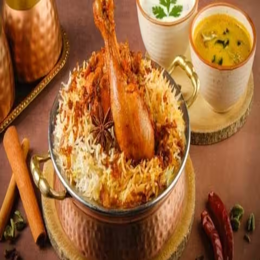

🍽️ Predicted Food: lasagna
🔍 Confidence: 32.62%


In [48]:
predict_uploaded_image(uploader)
